In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Load train and test
train_df = pd.read_csv("C:\\Users\\VP678WV\\OneDrive - EY\\Documents\\Delivery_Delay\\data\\processed\\train_encoded3.csv")
test_df = pd.read_csv("C:\\Users\\VP678WV\\OneDrive - EY\\Documents\\Delivery_Delay\\data\\processed\\test_encoded3.csv")

In [3]:
# Replace 'target' with your actual target column name if different
X_train = train_df.drop('target', axis=1)
y_train = train_df['target']

X_test = test_df.drop('target', axis=1)
y_test = test_df['target']

y_train = y_train.astype('category')
y_test = y_test.astype('category')

In [4]:
best_params = {'n_estimators': 800,
 'max_depth': 27,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'bootstrap': False}

In [5]:
# Train with best params
# best_params = study.best_params
rf_best = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)

# Test accuracy
from sklearn.metrics import accuracy_score
y_pred = rf_best.predict(X_test)

In [6]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.6311897106109324


In [7]:
import joblib
joblib.dump(rf_best, "rf_model_compressed.joblib", compress=("xz", 3))

['rf_model_compressed.joblib']

In [12]:
# Load compressed model
model_compressed = joblib.load("rf_model_compressed.joblib")

In [10]:
# Load compressed model
model_compressed = joblib.load("rf_model.joblib")

In [13]:
# # Load compressed model
# model_compressed = joblib.load("rf_model_compressed.joblib")
y_pred_comp = model_compressed.predict(X_test)
comp_acc = accuracy_score(y_test, y_pred_comp)

print(f"Compressed accuracy: {comp_acc:.4f}")

Compressed accuracy: 0.6312


In [11]:
# Load compressed model
model_compressed = joblib.load("rf_model.joblib")
y_pred_comp = model_compressed.predict(X_test)
comp_acc = accuracy_score(y_test, y_pred_comp)

print(f"Compressed accuracy: {comp_acc:.4f}")

Compressed accuracy: 0.6312


In [14]:
import numpy as np

def prune_forest(rf_model, keep_fraction=0.5, X_val=None, y_val=None):
    """
    Keep only the top fraction of trees based on importance.
    keep_fraction: 0.5 keeps top 50% important trees.
    """
    # Tree importances from OOB or permutation
    importances = np.array([estimator.tree_.compute_feature_importances(normalize=False).sum()
                            for estimator in rf_model.estimators_])
    
    # Sort by importance
    idx_sorted = np.argsort(importances)[::-1]
    keep_count = int(len(idx_sorted) * keep_fraction)
    
    # Keep only top trees
    rf_model.estimators_ = [rf_model.estimators_[i] for i in idx_sorted[:keep_count]]
    
    # Recompute n_estimators
    rf_model.n_estimators = len(rf_model.estimators_)
    return rf_model


In [15]:
pruned_model = prune_forest(rf_best, keep_fraction=0.5)

In [16]:
y_pred = pruned_model.predict(X_test)

In [17]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.6302250803858521


In [18]:
import joblib
joblib.dump(pruned_model, "rf_model_pruned.joblib")
joblib.dump(pruned_model, "rf_model_pruned_compresses.joblib", compress=("xz", 3))

['rf_model_pruned_compresses.joblib']

In [21]:
# Load compressed model
model_pruned = joblib.load("rf_model_pruned.joblib")

In [22]:
y_pred_comp = model_pruned.predict(X_test)
comp_acc = accuracy_score(y_test, y_pred_comp)

print(f"Compressed accuracy: {comp_acc:.4f}")

Compressed accuracy: 0.6302


In [23]:
model_pruned_c = joblib.load("rf_model_pruned_compresses.joblib")

In [24]:
y_pred_comp = model_pruned_c.predict(X_test)
comp_acc = accuracy_score(y_test, y_pred_comp)

print(f"Compressed accuracy: {comp_acc:.4f}")

Compressed accuracy: 0.6302


In [25]:
import shap

c:\Users\VP678WV\OneDrive - EY\Documents\Delivery_Delay\logistic_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
X_test.head(1)

,profit_per_order,order_item_discount,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_profit_per_order,shipping_mode,distance_normalized,order_to_shipment_days,...,performance_score_order_dayofweek,performance_score_shipping_dayofweek,performance_score_order_hour,performance_score_shipping_hour,performance_score_order_daynight,performance_score_ship_daynight,payment_type_CASH,payment_type_DEBIT,payment_type_PAYMENT,payment_type_TRANSFER
0,0.683672,0.005951,0.024097,0.809524,0.25,0.031561,0.718695,1,0.477075,0.333333,...,0.573129,1.0,0.697749,0.797124,0.396761,0.360476,False,False,False,True


In [27]:
# ---- 2. Select one sample ----
row_index = 0
one_sample = X_test.iloc[[row_index]]  # double brackets keep it as DataFrame
one_sample_dict = one_sample.to_dict(orient="records")[0]  # dict form

print("Sample as dictionary:", one_sample_dict)

Sample as dictionary: {'profit_per_order': 0.6836723710715507, 'order_item_discount': 0.005951012066503, 'order_item_product_price': 0.0240972565273443, 'order_item_profit_ratio': 0.8095238095238095, 'order_item_quantity': 0.25, 'sales': 0.0315605524675762, 'order_profit_per_order': 0.7186951173555055, 'shipping_mode': 1, 'distance_normalized': 0.4770750476924615, 'order_to_shipment_days': 0.3333333333333333, 'order_shipping_time': 0.2727272727272727, 'order_to_shipment_planned_days': 1.0, 'shipment_delay_days': 0.2, 'performance_score_order_full_location': 0.7083333333333333, 'performance_score_customer_full_location': 0.7222222222222223, 'performance_score_order_dayofweek': 0.5731290467165717, 'performance_score_shipping_dayofweek': 1.0, 'performance_score_order_hour': 0.697749133615992, 'performance_score_shipping_hour': 0.7971243180341703, 'performance_score_order_daynight': 0.3967607981553485, 'performance_score_ship_daynight': 0.3604763214213271, 'payment_type_CASH': False, 'paym

In [29]:
# ---- 3. Make prediction ----
pred_class = model_pruned_c.predict(one_sample)[0]
pred_proba = model_pruned_c.predict_proba(one_sample)[0]
print("Predicted class:", pred_class)
print("Predicted probabilities:", pred_proba)
print("Predicted Class:", pred_class)
print("Predicted Probabilities:", dict(zip(model_pruned_c.classes_, pred_proba)))

Predicted class: -1
Predicted probabilities: [0.54466667 0.1975     0.25783333]
Predicted Class: -1
Predicted Probabilities: {np.int64(-1): np.float64(0.5446666666666666), np.int64(0): np.float64(0.1975), np.int64(1): np.float64(0.2578333333333333)}


In [31]:
# ---- 4. Get SHAP values for that row ----
explainer = shap.TreeExplainer(model_pruned_c)  # works for RandomForest, XGB, LightGBM
shap_values = explainer.shap_values(one_sample)

In [32]:
shap_values

array([[[ 3.41090432e-03, -9.96016880e-03,  6.54926448e-03],
        [ 1.59671344e-02, -7.84757580e-03, -8.11955857e-03],
        [ 1.76293543e-02, -3.94683618e-02,  2.18390075e-02],
        [-4.60592047e-03,  1.64142783e-03,  2.96449264e-03],
        [-5.55864722e-03,  2.67171723e-04,  5.29147550e-03],
        [ 7.82522889e-03, -1.36221421e-02,  5.79691325e-03],
        [-8.02903051e-03, -9.47320311e-05,  8.12376254e-03],
        [ 6.86679869e-02,  7.25744444e-03, -7.59254313e-02],
        [ 9.06754193e-03, -8.07199882e-03, -9.95543105e-04],
        [-5.37014118e-03,  7.35215184e-03, -1.98201065e-03],
        [-4.06478116e-03,  5.85124959e-03, -1.78646843e-03],
        [ 6.50188230e-02,  2.08677535e-03, -6.71055983e-02],
        [ 2.12631429e-02, -7.09742444e-03, -1.41657185e-02],
        [ 1.55969135e-02,  2.45650450e-02, -4.01619585e-02],
        [-9.29338412e-03,  3.72157971e-02, -2.79224130e-02],
        [ 1.53391459e-02, -1.91200053e-02,  3.78085936e-03],
        [ 6.18260083e-03

In [33]:
# If classification → shap_values is list (one per class)
if isinstance(shap_values, list):
    shap_row_values = [dict(zip(X_test.columns, shap_values[c][0])) for c in range(len(shap_values))]
else:
    shap_row_values = dict(zip(X_test.columns, shap_values[0]))

print("SHAP values for each class:")
print(shap_row_values)

SHAP values for each class:
{'profit_per_order': array([ 0.0034109 , -0.00996017,  0.00654926]), 'order_item_discount': array([ 0.01596713, -0.00784758, -0.00811956]), 'order_item_product_price': array([ 0.01762935, -0.03946836,  0.02183901]), 'order_item_profit_ratio': array([-0.00460592,  0.00164143,  0.00296449]), 'order_item_quantity': array([-0.00555865,  0.00026717,  0.00529148]), 'sales': array([ 0.00782523, -0.01362214,  0.00579691]), 'order_profit_per_order': array([-8.02903051e-03, -9.47320311e-05,  8.12376254e-03]), 'shipping_mode': array([ 0.06866799,  0.00725744, -0.07592543]), 'distance_normalized': array([ 0.00906754, -0.008072  , -0.00099554]), 'order_to_shipment_days': array([-0.00537014,  0.00735215, -0.00198201]), 'order_shipping_time': array([-0.00406478,  0.00585125, -0.00178647]), 'order_to_shipment_planned_days': array([ 0.06501882,  0.00208678, -0.0671056 ]), 'shipment_delay_days': array([ 0.02126314, -0.00709742, -0.01416572]), 'performance_score_order_full_loc

In [38]:
# Map predicted *label* to the *index* that SHAP uses
cls_idx = int(np.where(model_pruned_c.classes_ == pred_class)[0][0])

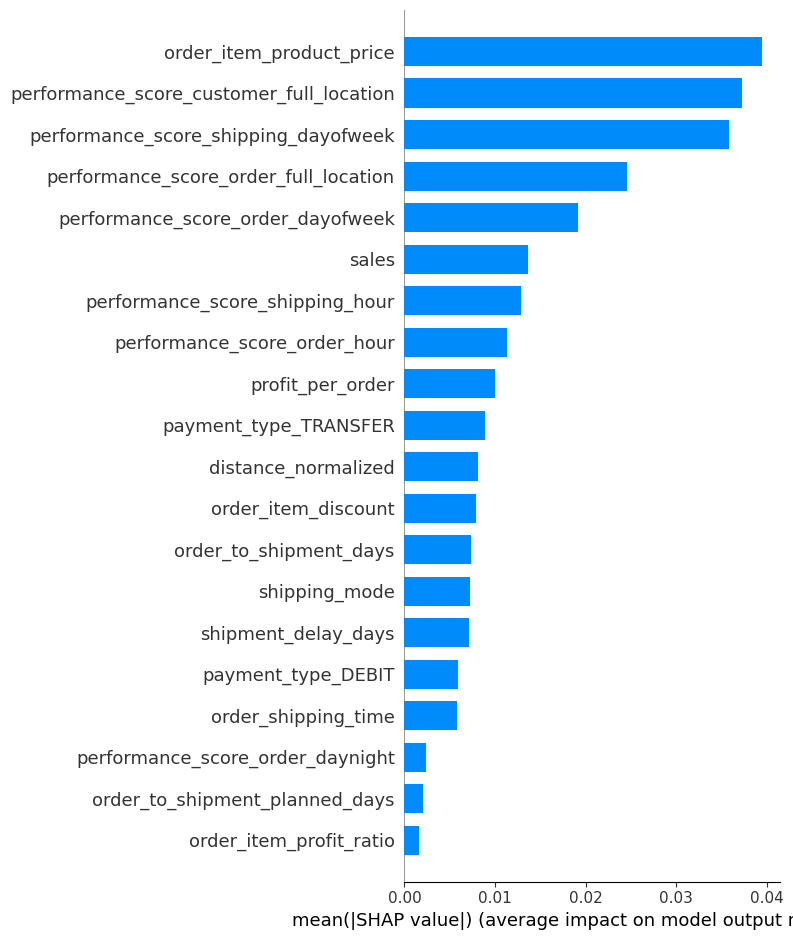

In [41]:
shap.summary_plot(shap_values[:, :, 1], one_sample, plot_type="bar")